In [1]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator
from src.graphconstruction import StaticGraphOrchestrator, DynamicGraphOrchestrator

disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 1
sequence_length = 1
lag_num         = 1

config= EpiConfig(
    disease             = 'influenza',
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = False,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'incidence',
    lag_column          = 'incidence',  
    verbose             = 0,
    predict_difference  = True,
    normalization_method='none'
    )   


data_orchestrator = DataOrchestrator(config).build()

In [2]:
df = data_orchestrator.data_final.data.copy()

df['target_lead1_diff'] = df.groupby('node').apply(
    lambda group: group['target_lead1'] - group['incidence_t0']
).reset_index(level=0, drop=True)

# Replace target_lead1 with the difference
df['target_lead1'] = df['target_lead1_diff']
df = df.drop(columns=['target_lead1_diff'])

data_orchestrator.data_final.data = df

/local/job_24123313/ipykernel_1972942/2133179198.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df['target_lead1_diff'] = df.groupby('node').apply(


<Axes: xlabel='timestamp', ylabel='target_lead1'>

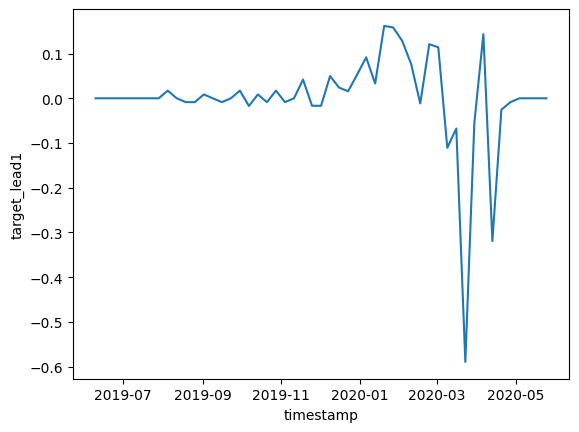

In [10]:
import seaborn as sns 

dfnode = df[df['node'] == 26]

sns.lineplot(dfnode[dfnode['test']], x = 'timestamp', y ='target_lead1')

In [3]:
from src.dataloading import BaseLineDataLoaderManager, GraphDataLoaderManager

In [11]:
n_epochs        = 100
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

baselinedata             = BaseLineDataLoaderManager(data_orchestrator)
graphdataloader_ig       = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('identity_graph').construct_dataloaders()
graphdataloader_gn       = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('geographical_neighbors1').construct_dataloaders()
graphdataloader_cm11     = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('static_commuter14_1').construct_dataloaders()
graphdataloader_cm12     = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('static_commuter14_2').construct_dataloaders()
graphdataloader_cm13     = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('static_commuter14_3').construct_dataloaders()
graphdataloader_cm14     = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('static_commuter14_4').construct_dataloaders()
graphdataloader_cm21     = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('static_commuter24_1').construct_dataloaders()
graphdataloader_cm22     = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('static_commuter24_2').construct_dataloaders()
graphdataloader_cm23     = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('static_commuter24_3').construct_dataloaders()
graphdataloader_cm24     = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('static_commuter24_4').construct_dataloaders()

In [12]:
from src.models import SimpleGCNModel, GATv2LSTMModel


==                  spatialgnn                  ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
Epoch 001 train loss: 0.0218, val loss: 0.0284 ✓ (new best)
Epoch 002 train loss: 0.0194, val loss: 0.0269 ✓ (new best)
Epoch 003 train loss: 0.0189, val loss: 0.0261 ✓ (new best)
Epoch 004 train loss: 0.0186, val loss: 0.0256 ✓ (new best)
Epoch 005 train loss: 0.0184, val loss: 0.0253 ✓ (new best)
Epoch 006 train loss: 0.0183, val loss: 0.0250 ✓ (new best)
Epoch 007 train loss: 0.0182, val loss: 0.0247 ✓ (new best)
Epoch 008 train loss: 0.0181, val loss: 0.0244 ✓ (new best)
Epoch 009 train loss: 0.0180, val loss: 0.0242 ✓ (new best)
Epoch 010 train loss: 0.0179, val loss: 0.0240 ✓ (new best)
Epoch 011 train loss: 0.0179, val loss: 0.0238 ✓ (new best)
Epoch 012 train loss: 0.0178, val loss: 0.0237 ✓ (new best)
Epoch 013 train loss: 0.0177, val loss: 0.0235 ✓ (new best)
Epoch 014 train loss: 0.0177

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:254: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.0217
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 647.32it/s]

Test loss: 0.0372
forecasted ✓


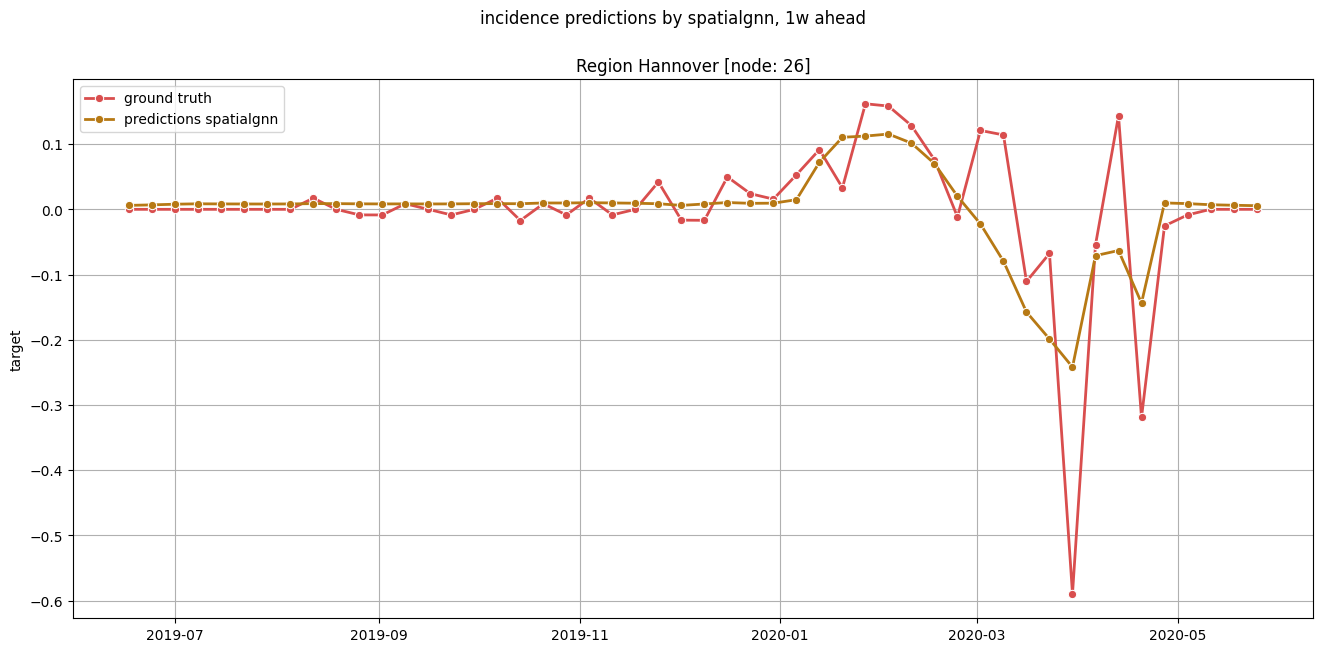

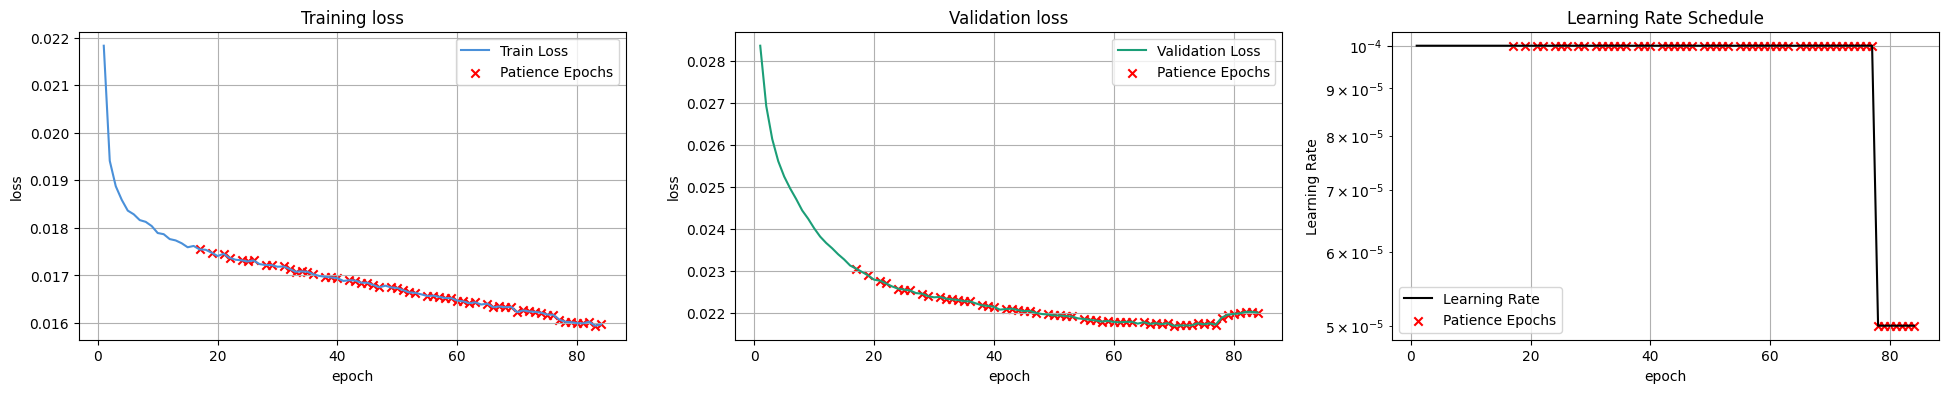

In [ ]:
gcn1 = SimpleGCNModel(graphdataloader_ig, name = 'model1', verbose = 10)
gcn1.set_model_hparams()
gcn1.set_global_hparams(**global_hparams)
gcn1.train()
gcn1.forecast()
gcn1.show_forecasts(26).show()


==                  spatialgnn                  ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 001 train loss: 0.0199, val loss: 0.0292 ✓ (new best)
Epoch 002 train loss: 0.0194, val loss: 0.0283 ✓ (new best)
Epoch 003 train loss: 0.0192, val loss: 0.0275 ✓ (new best)
Epoch 004 train loss: 0.0190, val loss: 0.0268 ✓ (new best)
Epoch 005 train loss: 0.0189, val loss: 0.0262 ✓ (new best)
Epoch 006 train loss: 0.0188, val loss: 0.0258 ✓ (new best)
Epoch 007 train loss: 0.0186, val loss: 0.0253 ✓ (new best)
Epoch 008 train loss: 0.0186, val loss: 0.0250 ✓ (new best)
Epoch 009 train loss: 0.0185, val loss: 0.0247 ✓ (new best)
Epoch 010 train loss: 0.0184, val loss: 0.0244 ✓ (new best)
Epoch 011 train loss: 0.0184, val loss: 0.0243 ✓ (new best)
Epoch 012 train loss: 0.0183, val loss: 0.0241 ✓ (new best)
Epoch 013 train loss: 0.0183, val loss: 0.0239 ✓ (new best)
Epoch 014 train loss: 0.01

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:254: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.0228
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 630.79it/s]

Test loss: 0.0397
forecasted ✓


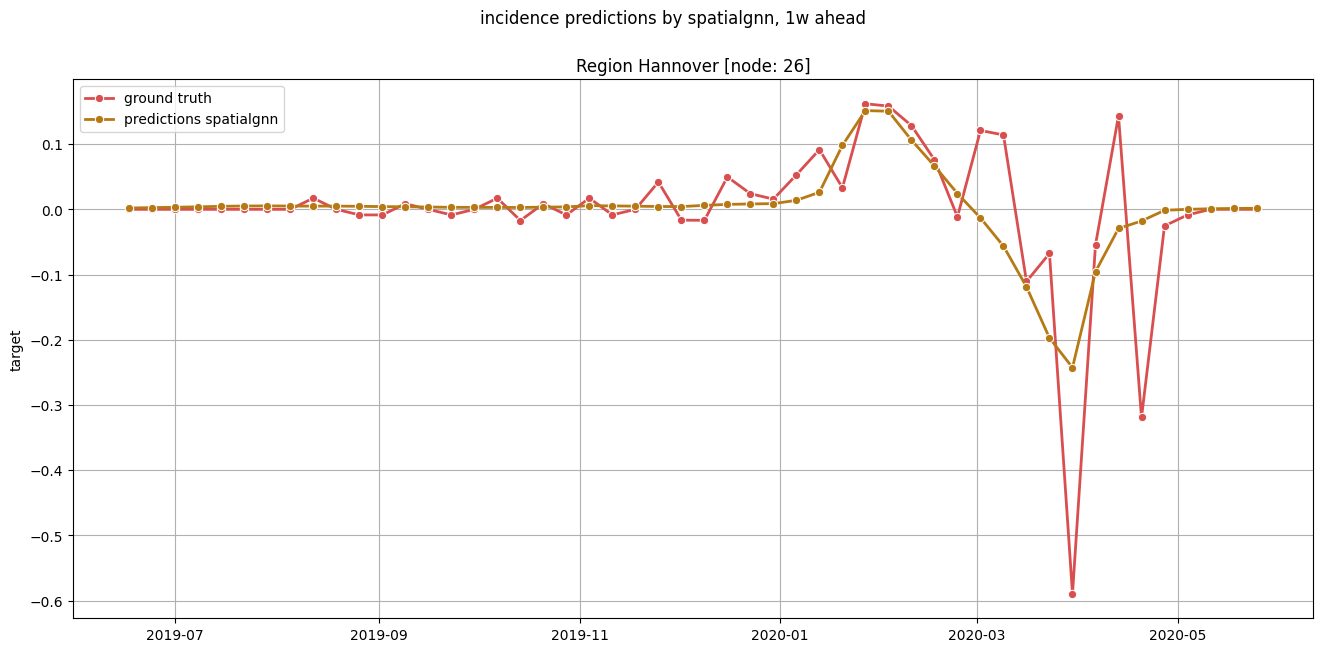

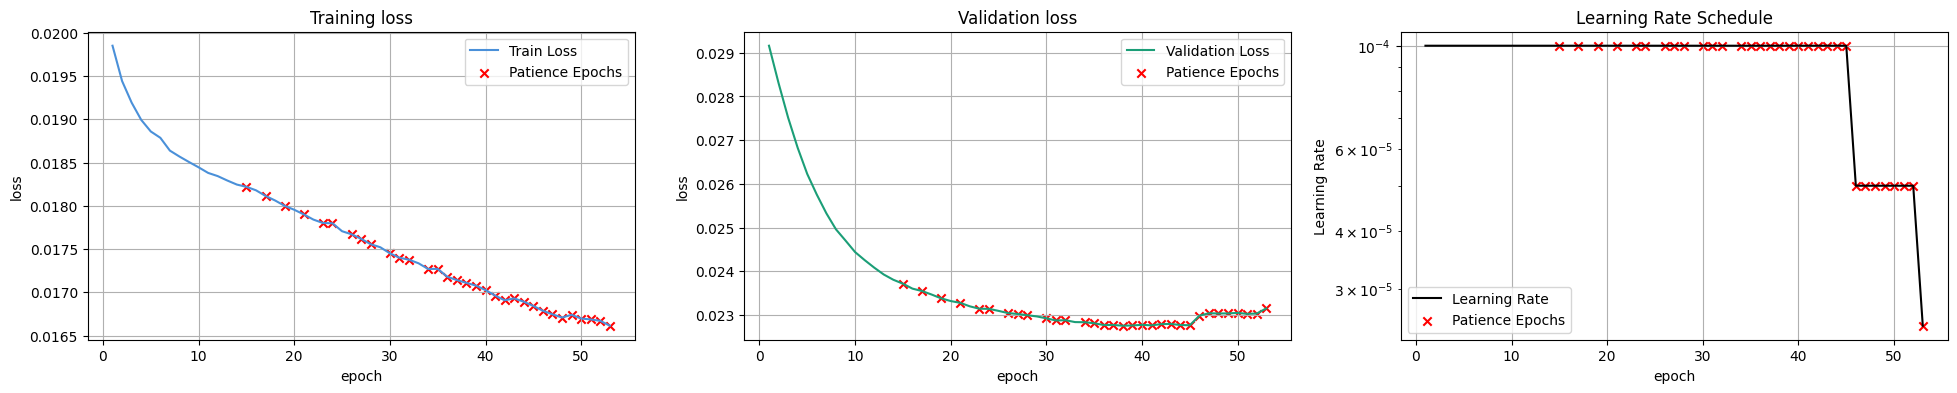

In [ ]:
gcn2 = SimpleGCNModel(graphdataloader_gn, name = 'model2', verbose = 10)
gcn2.set_model_hparams()
gcn2.set_global_hparams(**global_hparams)
gcn2.train()
gcn2.forecast()
gcn2.show_forecasts(26).show()


==                    model3                    ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 001 train loss: 0.0227, val loss: 0.0308 ✓ (new best)
Epoch 002 train loss: 0.0207, val loss: 0.0300 ✓ (new best)
Epoch 003 train loss: 0.0201, val loss: 0.0268 ✓ (new best)
Epoch 004 train loss: 0.0198, val loss: 0.0320 (patience: 1/20)
Epoch 005 train loss: 0.0199, val loss: 0.0283 (patience: 2/20)
Epoch 006 train loss: 0.0197, val loss: 0.0322 (patience: 3/20)
Epoch 007 train loss: 0.0199, val loss: 0.0279 (patience: 4/20)
Epoch 008 train loss: 0.0194, val loss: 0.0330 (patience: 5/20)
Epoch 009 train loss: 0.0196, val loss: 0.0316 (patience: 6/20)
Epoch 010 train loss: 0.0193, val loss: 0.0324 (patience: 7/20)
lr has been updated from 1.00e-04 to 5.00e-05
Epoch 011 train loss: 0.0196, val loss: 0.0277 (patience: 8/20)
Epoch 012 train loss: 0.0190, val loss: 0.0293 (patience: 9/20)
Epoc

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:254: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.0233
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 464.41it/s]


Test loss: 0.0392
forecasted ✓


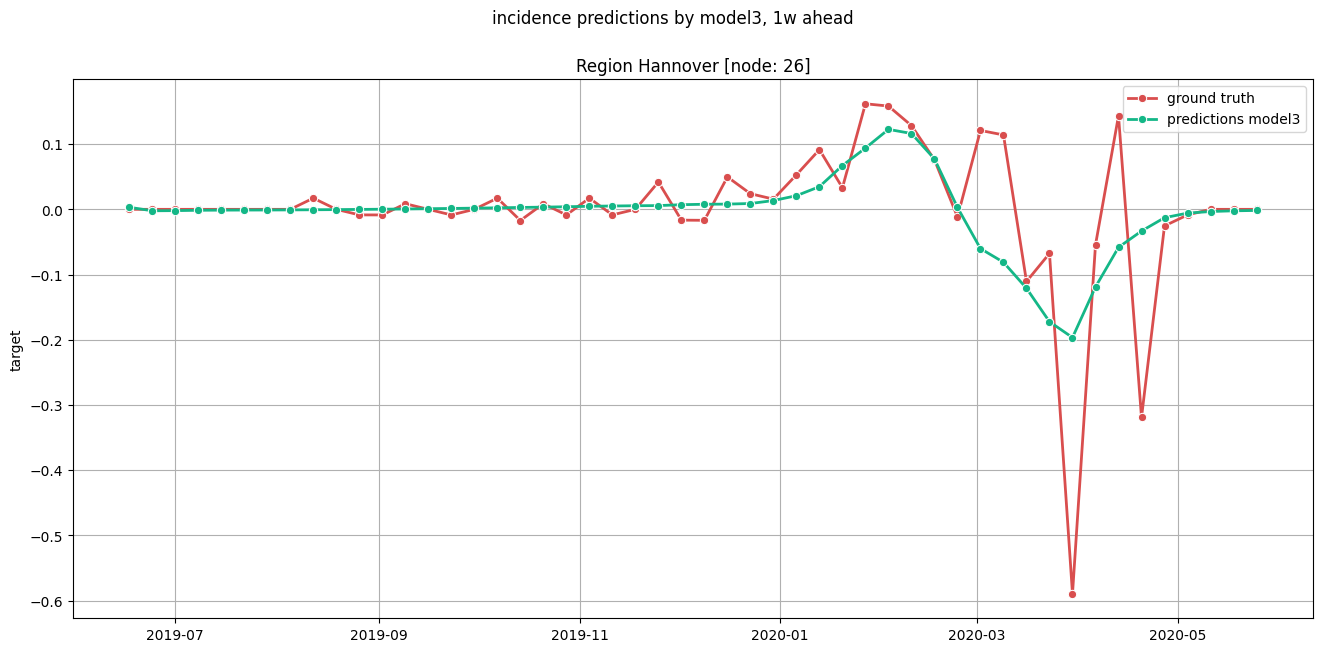

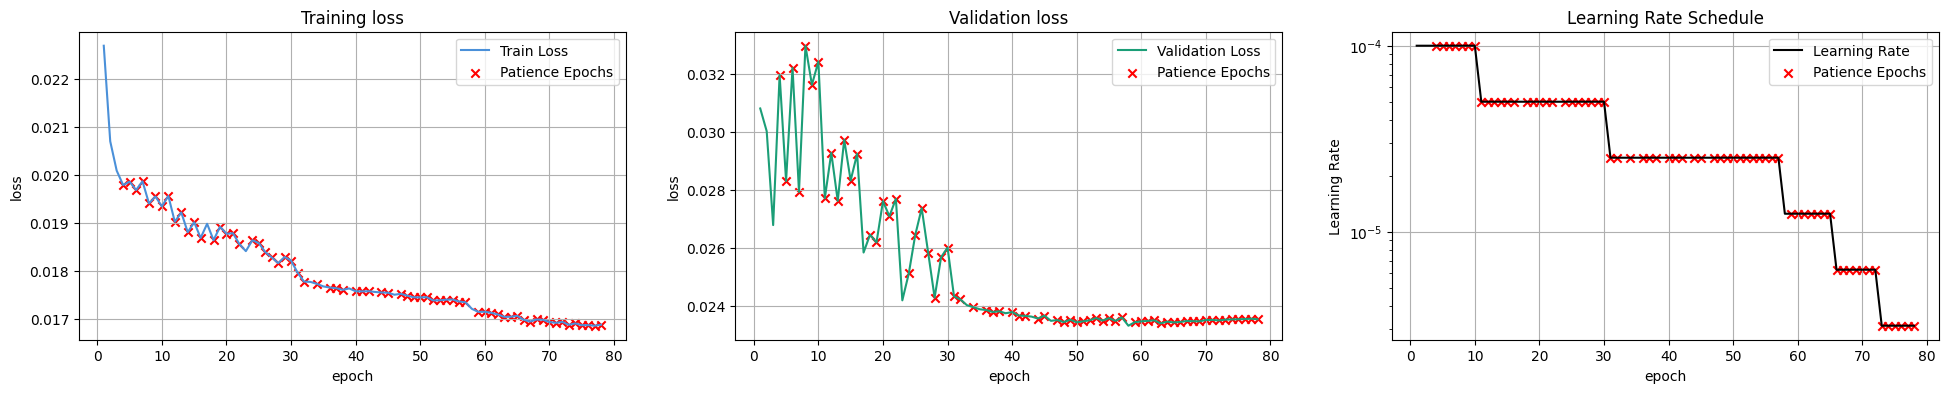

In [17]:
gat = GATv2LSTMModel(graphdataloader_gn, name = 'model3', verbose = 10)
gat.set_model_hparams()
gat.set_global_hparams(**global_hparams)
gat.train()
gat.forecast()
gat.show_forecasts(26).show()


==                    model4                    ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 2372), edge_weight=(2372,))
Epoch 001 train loss: 0.0224, val loss: 0.0294 ✓ (new best)
Epoch 002 train loss: 0.0209, val loss: 0.0289 ✓ (new best)
Epoch 003 train loss: 0.0203, val loss: 0.0276 ✓ (new best)
Epoch 004 train loss: 0.0200, val loss: 0.0312 (patience: 1/20)
Epoch 005 train loss: 0.0199, val loss: 0.0277 (patience: 2/20)
Epoch 006 train loss: 0.0198, val loss: 0.0312 (patience: 3/20)
Epoch 007 train loss: 0.0197, val loss: 0.0299 (patience: 4/20)
Epoch 008 train loss: 0.0196, val loss: 0.0312 (patience: 5/20)
Epoch 009 train loss: 0.0197, val loss: 0.0286 (patience: 6/20)
Epoch 010 train loss: 0.0193, val loss: 0.0329 (patience: 7/20)
lr has been updated from 1.00e-04 to 5.00e-05
Epoch 011 train loss: 0.0193, val loss: 0.0283 (patience: 8/20)
Epoch 012 train loss: 0.0191, val loss: 0.0292 (patience: 9/20)
Epoc

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:254: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.0233
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 464.59it/s]


Test loss: 0.0395
forecasted ✓


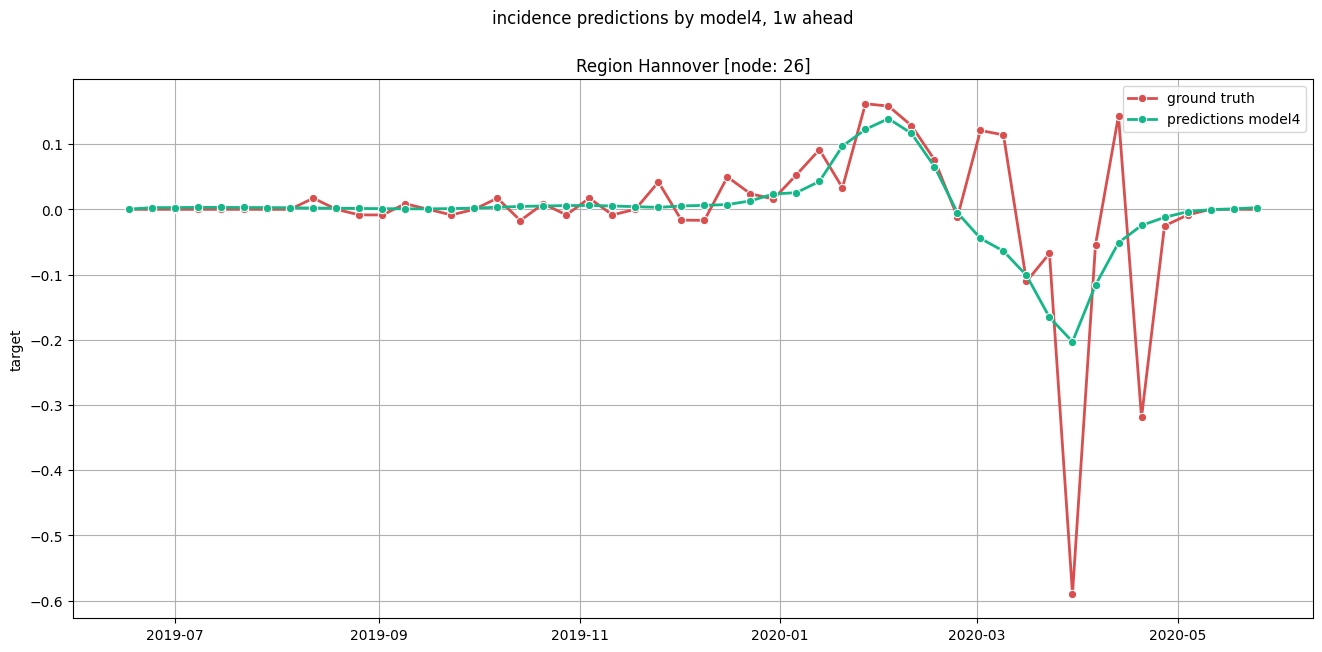

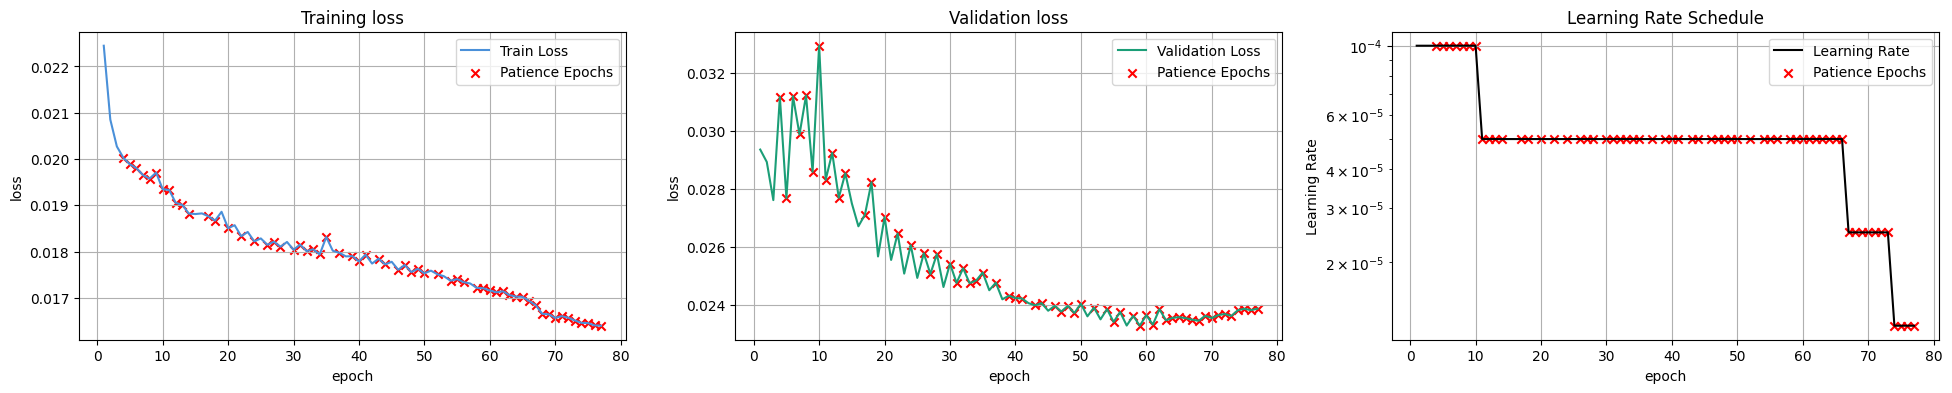

In [20]:
gat = GATv2LSTMModel(graphdataloader_cm12, name = 'model4', verbose = 10)
gat.set_model_hparams()
gat.set_global_hparams(**global_hparams)
gat.train()
gat.forecast()
gat.show_forecasts(26).show()

computing metrics:   0%|                                                                                  | 0/6 [00:00<?, ?it/s]

computing metrics: 100%|██████████████████████████████████████████████████████████████████████████| 6/6 [00:02<00:00,  2.04it/s]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabe

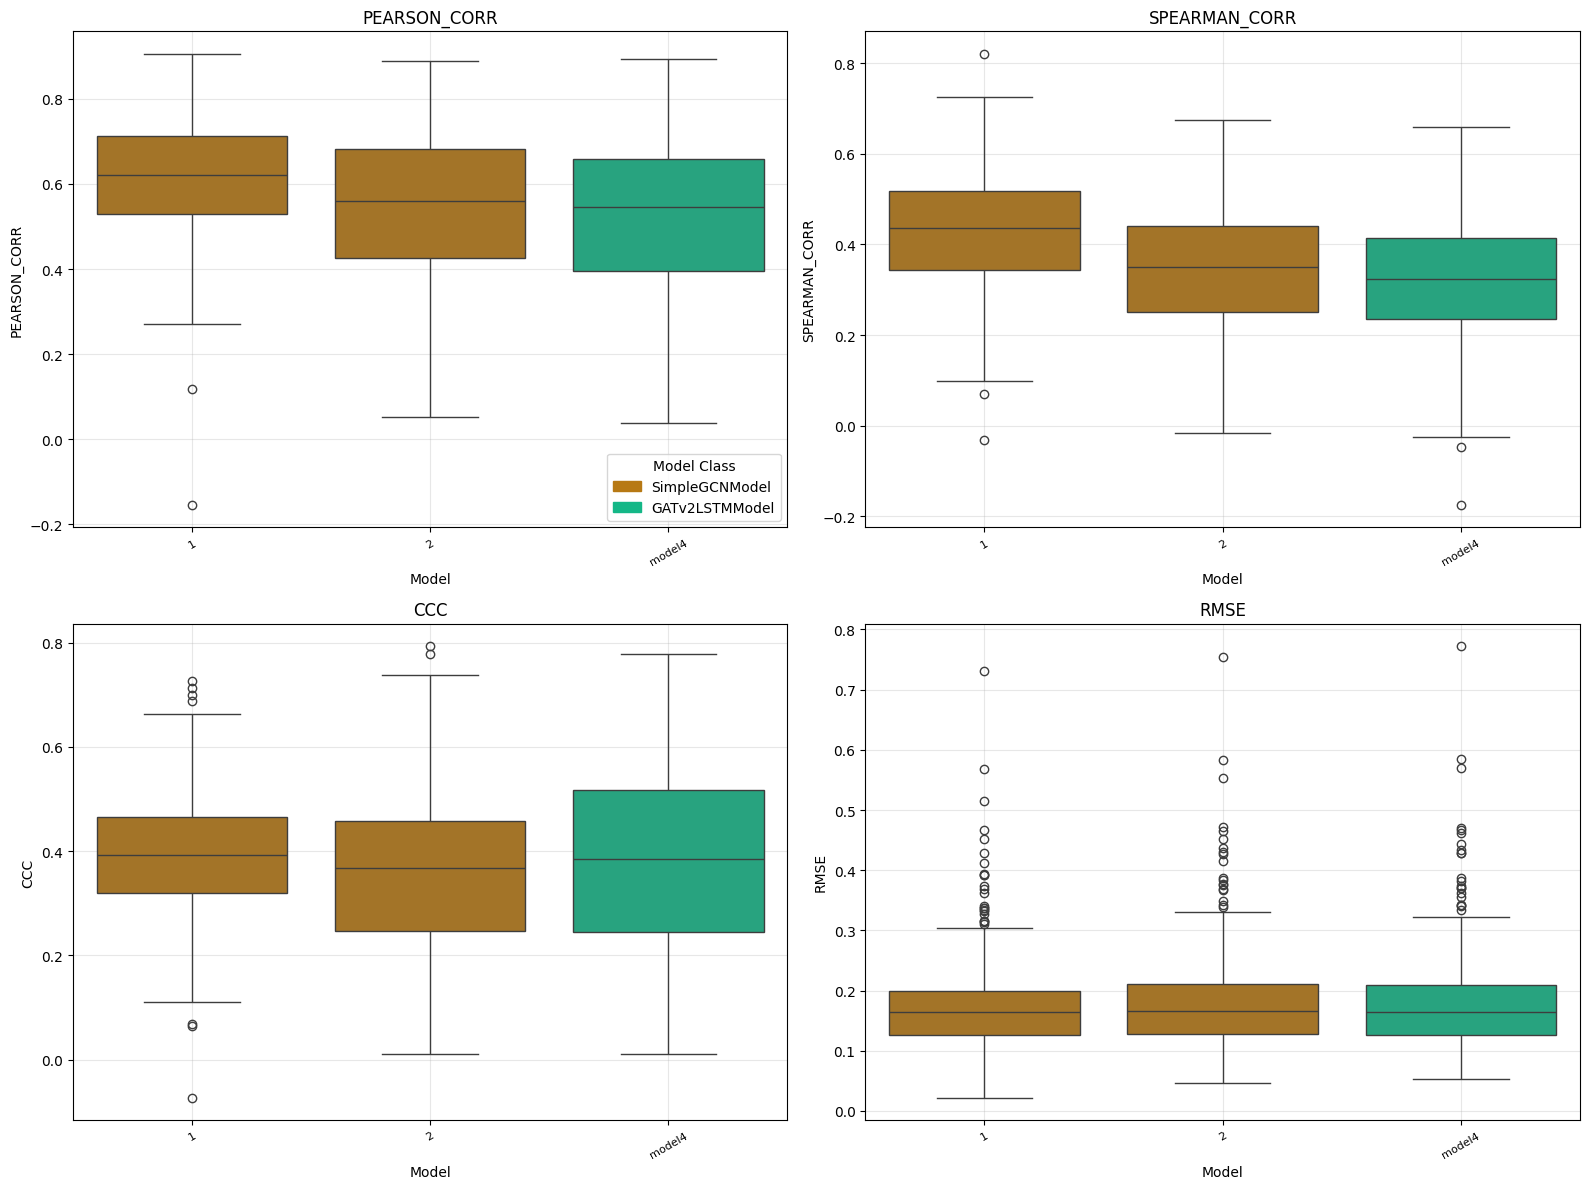

In [21]:
from src.evaluation import Evaluator 
e = Evaluator([gcn1, gcn2, gat]).add_evaluation()
e.plotter.plot_metric_compilation().show()